### [Intraday Volatility Jump Mean-Reversion (JMR) Trading Strategy](https://medium.com/@alexzap922/06dff96ce939)

> Bias-Free Profitability of Volatility Jumps with Overnight Gaps Using 1-Minute OHLC Candle Data from Bitstamp

In [1]:
import sys

IN_COLAB = 'google.colab' in sys.modules

import warnings
warnings.filterwarnings('ignore')

from IPython.display import display

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

np.random.seed(42)
np.set_printoptions(precision=4)

pd.set_option('display.width', None)
pd.set_option('display.precision', 4)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', '{:.4f}'.format)

%autosave 10

Autosaving every 10 seconds


In [2]:
base_url = "https://ff137.github.io/bitstamp-btcusd-minute-data/data/historical"
df = pd.read_csv(
  f"{base_url}/btcusd_bitstamp_1min_2012-2025.csv.gz",
  compression="gzip"
)
df["timestamp"] = pd.to_datetime(df["timestamp"], unit="s")
df = df.sort_values("timestamp").reset_index(drop=True)

display(df.tail(10))

,timestamp,open,high,low,close,volume
6846590,2025-01-06 23:51:00,102217.0000,102225.0000,102213.0000,102222.0000,0.0833
6846591,2025-01-06 23:52:00,102241.0000,102246.0000,102240.0000,102240.0000,0.2010
6846592,2025-01-06 23:53:00,102234.0000,102242.0000,102230.0000,102238.0000,0.1069
6846593,2025-01-06 23:54:00,102237.0000,102237.0000,102225.0000,102227.0000,0.1113
6846594,2025-01-06 23:55:00,102227.0000,102232.0000,102225.0000,102232.0000,0.1193
6846595,2025-01-06 23:56:00,102231.0000,102231.0000,102227.0000,102227.0000,0.0689
6846596,2025-01-06 23:57:00,102230.0000,102232.0000,102230.0000,102232.0000,0.1995
6846597,2025-01-06 23:58:00,102262.0000,102280.0000,102260.0000,102280.0000,0.1044
6846598,2025-01-06 23:59:00,102280.0000,102280.0000,102280.0000,102280.0000,0.0076
6846599,2025-01-07 00:00:00,102278.0000,102291.0000,102263.0000,102263.0000,0.5231


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6846600 entries, 0 to 6846599
Data columns (total 6 columns):
 #   Column     Dtype         
---  ------     -----         
 0   timestamp  datetime64[ns]
 1   open       float64       
 2   high       float64       
 3   low        float64       
 4   close      float64       
 5   volume     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 313.4 MB


In [4]:
# Select last ~20000 rows
sample = df.iloc[-20000:].copy()

# Ensure datetime
sample['timestamp'] = pd.to_datetime(sample['timestamp'])

fig = make_subplots(
  rows=2, cols=1,
  shared_xaxes=True,
  vertical_spacing=0.03,
  row_heights=[0.7, 0.3]
)

# --- Candlestick ---
fig.add_trace(
  go.Candlestick(
    x=sample['timestamp'],
    open=sample['open'],
    high=sample['high'],
    low=sample['low'],
    close=sample['close'],
    name='BTC-USD'
  ),
  row=1, col=1
)

# --- Volume ---


fig.add_trace(
  go.Bar(
    x=sample['timestamp'],
    y=sample['volume'],
    marker=dict(color='black'),
    name='Volume',
    opacity=1
  ),
  row=2, col=1
)
# Layout
fig.update_layout(
  title='BTC-USD Candlestick with Volume (1-Minute)',
  xaxis_rangeslider_visible=False,
  plot_bgcolor='white',
  height=800
)

# --- X-axis grid lines ---
fig.update_xaxes(
  showgrid=True,         # enable grid
  gridcolor='lightgray', # color of grid lines
  gridwidth=1,           # thickness
  row=1, col=1
)

# --- Y-axis grid lines for candlestick ---
fig.update_yaxes(
  showgrid=True,
  gridcolor='lightgray',
  gridwidth=1,
  row=1, col=1
)

# --- Y-axis grid lines for volume ---
fig.update_yaxes(
  showgrid=True,
  gridcolor='lightgray',
  gridwidth=1,
  row=2, col=1
)


fig.show()

In [5]:
df['date'] = df['timestamp'].dt.date #Extracts the calendar date from each timestamp
df['new_day'] = df['date'] != df['date'].shift(1) # flags the first minute of a new trading day

display(df.tail(10))

,timestamp,open,high,low,close,volume,date,new_day
6846590,2025-01-06 23:51:00,102217.0000,102225.0000,102213.0000,102222.0000,0.0833,2025-01-06,False
6846591,2025-01-06 23:52:00,102241.0000,102246.0000,102240.0000,102240.0000,0.2010,2025-01-06,False
6846592,2025-01-06 23:53:00,102234.0000,102242.0000,102230.0000,102238.0000,0.1069,2025-01-06,False
6846593,2025-01-06 23:54:00,102237.0000,102237.0000,102225.0000,102227.0000,0.1113,2025-01-06,False
6846594,2025-01-06 23:55:00,102227.0000,102232.0000,102225.0000,102232.0000,0.1193,2025-01-06,False
6846595,2025-01-06 23:56:00,102231.0000,102231.0000,102227.0000,102227.0000,0.0689,2025-01-06,False
6846596,2025-01-06 23:57:00,102230.0000,102232.0000,102230.0000,102232.0000,0.1995,2025-01-06,False
6846597,2025-01-06 23:58:00,102262.0000,102280.0000,102260.0000,102280.0000,0.1044,2025-01-06,False
6846598,2025-01-06 23:59:00,102280.0000,102280.0000,102280.0000,102280.0000,0.0076,2025-01-06,False
6846599,2025-01-07 00:00:00,102278.0000,102291.0000,102263.0000,102263.0000,0.5231,2025-01-07,True


In [6]:
# Close-to-close log returns (intraday)
df['log_ret_intraday'] = np.log(df['close'] / df['close'].shift(1)) # Shifts the closing price down by 1 row, so each row now has the previous minute’s close.
# This is essential because return at time t = (price now / price previous).

# Overnight returns: today open vs previous close
df['log_ret_overnight'] = np.log(df['open'] / df['close'].shift(1)) # the ratio of today’s open to yesterday’s close.

# df['open'] The opening price of the current candle (typically the first minute of the new trading day).
# df['close'].shift(1) The previous row’s close (usually the last minute of the previous day). This represents the last price available before the overnight period.

display(df.tail(10))

,timestamp,open,high,low,close,volume,date,new_day,log_ret_intraday,log_ret_overnight
6846590,2025-01-06 23:51:00,102217.0000,102225.0000,102213.0000,102222.0000,0.0833,2025-01-06,False,-0.0002,-0.0002
6846591,2025-01-06 23:52:00,102241.0000,102246.0000,102240.0000,102240.0000,0.2010,2025-01-06,False,0.0002,0.0002
6846592,2025-01-06 23:53:00,102234.0000,102242.0000,102230.0000,102238.0000,0.1069,2025-01-06,False,-0.0000,-0.0001
6846593,2025-01-06 23:54:00,102237.0000,102237.0000,102225.0000,102227.0000,0.1113,2025-01-06,False,-0.0001,-0.0000
6846594,2025-01-06 23:55:00,102227.0000,102232.0000,102225.0000,102232.0000,0.1193,2025-01-06,False,0.0000,0.0000
6846595,2025-01-06 23:56:00,102231.0000,102231.0000,102227.0000,102227.0000,0.0689,2025-01-06,False,-0.0000,-0.0000
6846596,2025-01-06 23:57:00,102230.0000,102232.0000,102230.0000,102232.0000,0.1995,2025-01-06,False,0.0000,0.0000
6846597,2025-01-06 23:58:00,102262.0000,102280.0000,102260.0000,102280.0000,0.1044,2025-01-06,False,0.0005,0.0003
6846598,2025-01-06 23:59:00,102280.0000,102280.0000,102280.0000,102280.0000,0.0076,2025-01-06,False,0.0000,0.0000
6846599,2025-01-07 00:00:00,102278.0000,102291.0000,102263.0000,102263.0000,0.5231,2025-01-07,True,-0.0002,-0.0000


In [7]:
# Replace first intraday return of each day with overnight return
df.loc[df['new_day'], 'log_ret_intraday'] = df.loc[df['new_day'], 'log_ret_overnight']

# Final return series (used for jumps)
df['log_ret'] = df['log_ret_intraday']

# Exclude overnight bars for volatility calculation
df['log_ret_intraday_vol'] = df['log_ret_intraday'].copy()
df.loc[df['new_day'], 'log_ret_intraday_vol'] = np.nan  # remove overnight returns

window = 60  # rolling window in minutes
df['vol'] = df['log_ret_intraday_vol'].rolling(window, min_periods=1).std()
#This will be used to detect “jumps”—price changes that are unusually large compared to recent volatility.

display(df.tail(10))

,timestamp,open,high,low,close,volume,date,new_day,log_ret_intraday,log_ret_overnight,log_ret,log_ret_intraday_vol,vol
6846590,2025-01-06 23:51:00,102217.0000,102225.0000,102213.0000,102222.0000,0.0833,2025-01-06,False,-0.0002,-0.0002,-0.0002,-0.0002,0.0005
6846591,2025-01-06 23:52:00,102241.0000,102246.0000,102240.0000,102240.0000,0.2010,2025-01-06,False,0.0002,0.0002,0.0002,0.0002,0.0005
6846592,2025-01-06 23:53:00,102234.0000,102242.0000,102230.0000,102238.0000,0.1069,2025-01-06,False,-0.0000,-0.0001,-0.0000,-0.0000,0.0005
6846593,2025-01-06 23:54:00,102237.0000,102237.0000,102225.0000,102227.0000,0.1113,2025-01-06,False,-0.0001,-0.0000,-0.0001,-0.0001,0.0005
6846594,2025-01-06 23:55:00,102227.0000,102232.0000,102225.0000,102232.0000,0.1193,2025-01-06,False,0.0000,0.0000,0.0000,0.0000,0.0005
6846595,2025-01-06 23:56:00,102231.0000,102231.0000,102227.0000,102227.0000,0.0689,2025-01-06,False,-0.0000,-0.0000,-0.0000,-0.0000,0.0005
6846596,2025-01-06 23:57:00,102230.0000,102232.0000,102230.0000,102232.0000,0.1995,2025-01-06,False,0.0000,0.0000,0.0000,0.0000,0.0005
6846597,2025-01-06 23:58:00,102262.0000,102280.0000,102260.0000,102280.0000,0.1044,2025-01-06,False,0.0005,0.0003,0.0005,0.0005,0.0005
6846598,2025-01-06 23:59:00,102280.0000,102280.0000,102280.0000,102280.0000,0.0076,2025-01-06,False,0.0000,0.0000,0.0000,0.0000,0.0004
6846599,2025-01-07 00:00:00,102278.0000,102291.0000,102263.0000,102263.0000,0.5231,2025-01-07,True,-0.0000,-0.0000,-0.0000,NaN,0.0004


In [8]:
k = 7 # is a multiplier that controls how extreme a move must be to be considered a “jump.”
df['jump'] = np.abs(df['log_ret']) > k * df['vol']

jumps = df[df['jump']]
print(f"Detected {len(jumps)} jumps")
display(jumps[['timestamp', 'open', 'close', 'log_ret', 'vol']].head())

Detected 4178 jumps


,timestamp,open,close,log_ret,vol
627,2012-01-01 20:28:00,4.8400,4.8400,0.0552,0.0071
1064,2012-01-02 03:45:00,5.0000,5.0000,0.0325,0.0042
3284,2012-01-03 16:45:00,5.3200,5.3200,0.0620,0.0080
3441,2012-01-03 19:22:00,5.1400,5.1400,-0.0344,0.0044
3613,2012-01-03 22:14:00,5.1400,5.1400,-0.0288,0.0037


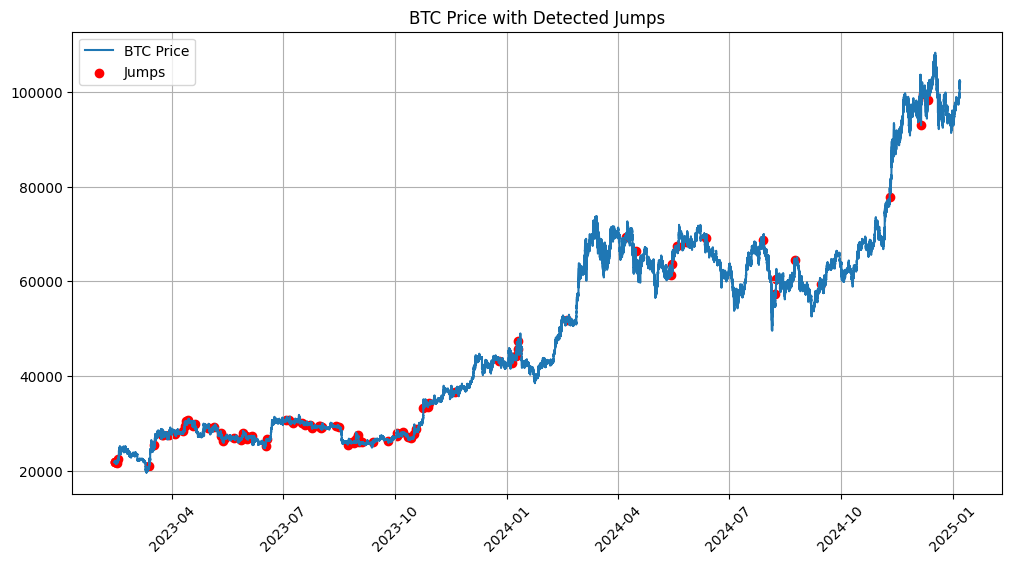

In [9]:
# Select a smaller time window (very important for readability)
sample = df.iloc[-1000000:]  # last 1000000 minutes

plt.figure(figsize=(12, 6))
plt.plot(sample['timestamp'], sample['close'], label='BTC Price')

# Overlay jumps
jump_points = sample[sample['jump']]
plt.scatter(jump_points['timestamp'], jump_points['close'], marker='o', label='Jumps',color='r')

plt.title("BTC Price with Detected Jumps")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

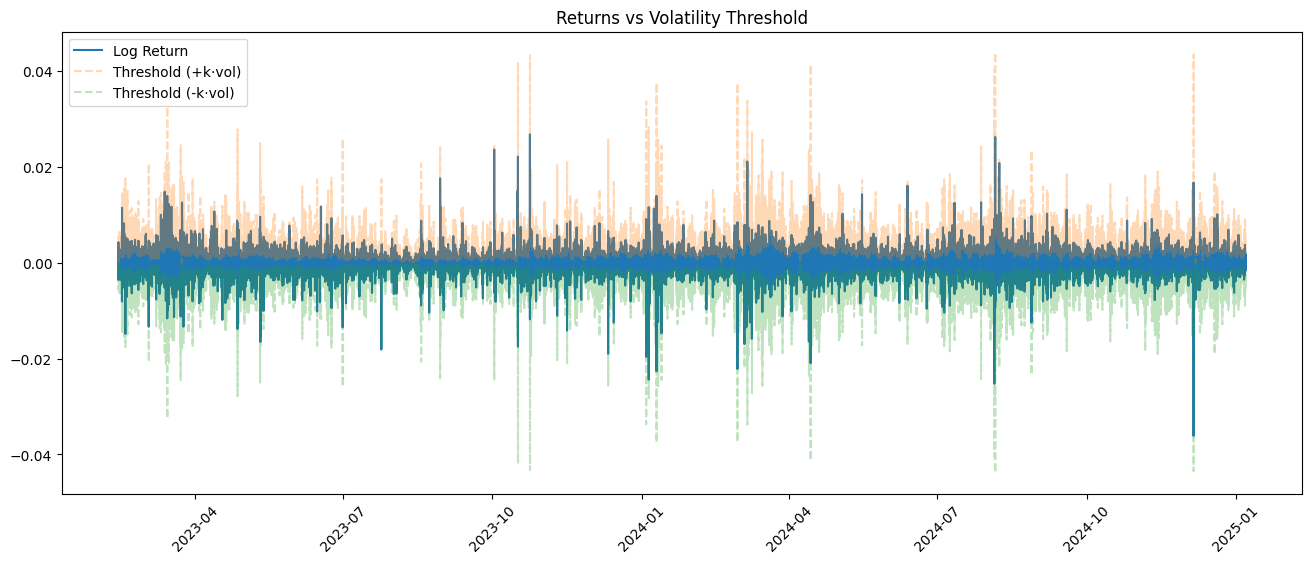

In [10]:
plt.figure(figsize=(16, 6))

plt.plot(sample['timestamp'], sample['log_ret'], label='Log Return')
plt.plot(sample['timestamp'], k * sample['vol'], linestyle='--', label='Threshold (+k·vol)',alpha=0.3)
plt.plot(sample['timestamp'], -k * sample['vol'], linestyle='--', label='Threshold (-k·vol)',alpha=0.3)

plt.title("Returns vs Volatility Threshold")
plt.legend()
plt.xticks(rotation=45)
plt.show()

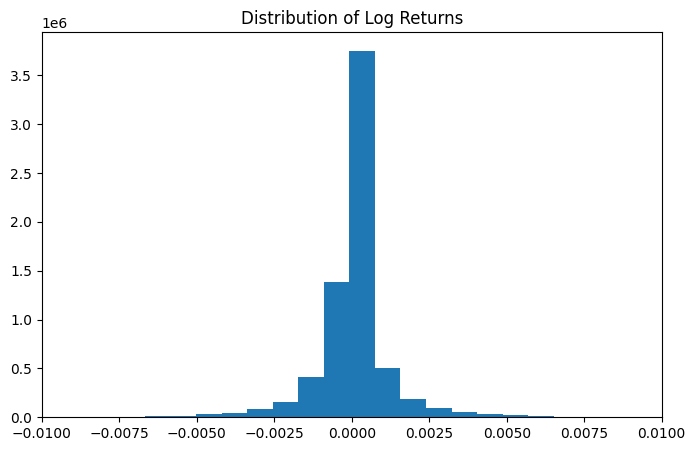

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(df['log_ret'].dropna(), bins=1500)
plt.title("Distribution of Log Returns")
plt.xlim([-0.01,0.01])
plt.show()

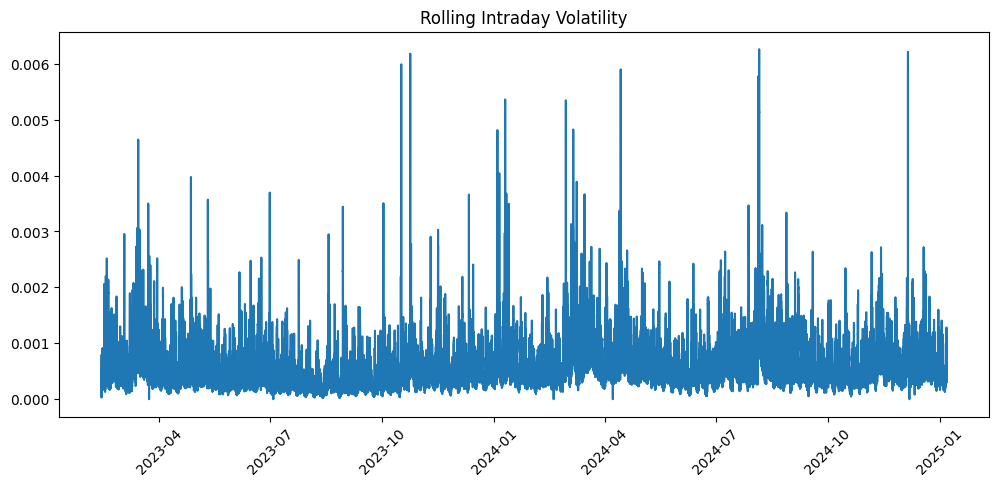

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(sample['timestamp'], sample['vol'])
plt.title("Rolling Intraday Volatility")
plt.xticks(rotation=45)
plt.show()

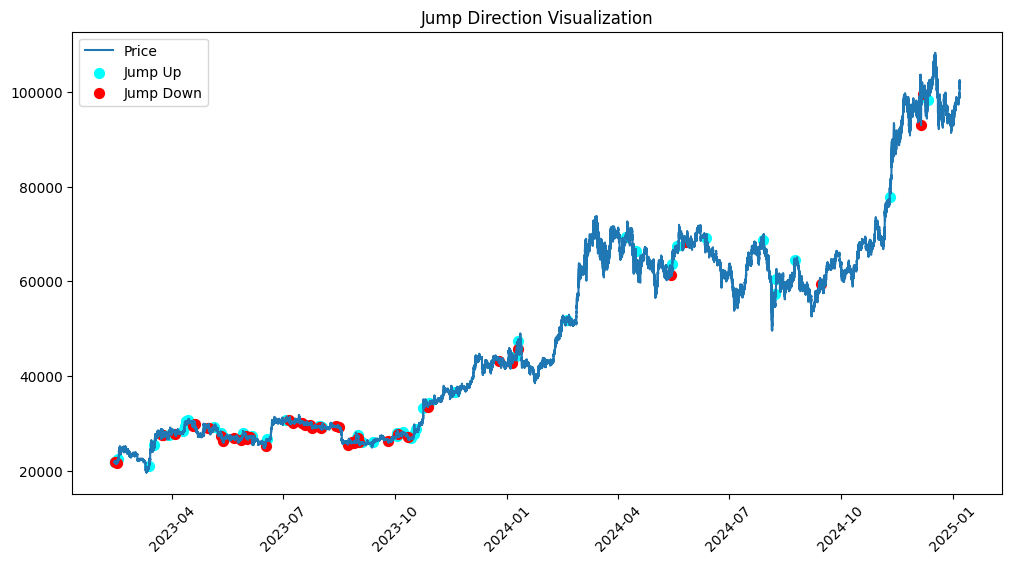

In [13]:
df['jump_up'] = df['log_ret'] > k * df['vol']
df['jump_down'] = df['log_ret'] < -k * df['vol']

sample = df.iloc[-1000000:]

plt.figure(figsize=(12, 6))
plt.plot(sample['timestamp'], sample['close'], label='Price')

plt.scatter(sample[sample['jump_up']]['timestamp'],
            sample[sample['jump_up']]['close'],
            label='Jump Up',color="cyan",s=50)

plt.scatter(sample[sample['jump_down']]['timestamp'],
            sample[sample['jump_down']]['close'],
            label='Jump Down',color="red",s=50)

plt.legend()
plt.title("Jump Direction Visualization")
plt.xticks(rotation=45)
plt.show()

In [14]:
# Positions: mean-reversion
df['position'] = 0
df.loc[df['jump_up'], 'position'] = -1   # short
df.loc[df['jump_down'], 'position'] = 1  # long

# Forward-fill positions (hold until next signal)
df['position'] = df['position'].replace(0, np.nan).ffill().fillna(0) #hold that position until a new signal appears
#Without this, you would only trade for 1 minute per signal.

df['strategy_ret'] = df['position'].shift(1) * df['log_ret']
df['cum_pnl'] = df['strategy_ret'].cumsum()
df['cum_pnl_exp'] = np.exp(df['cum_pnl'])  # convert log returns to equity

display(df.tail(10))

,timestamp,open,high,low,close,volume,date,new_day,log_ret_intraday,log_ret_overnight,log_ret,log_ret_intraday_vol,vol,jump,jump_up,jump_down,position,strategy_ret,cum_pnl,cum_pnl_exp
6846590,2025-01-06 23:51:00,102217.0000,102225.0000,102213.0000,102222.0000,0.0833,2025-01-06,False,-0.0002,-0.0002,-0.0002,-0.0002,0.0005,False,False,False,-1.0000,0.0002,17.7201,49628600.4111
6846591,2025-01-06 23:52:00,102241.0000,102246.0000,102240.0000,102240.0000,0.2010,2025-01-06,False,0.0002,0.0002,0.0002,0.0002,0.0005,False,False,False,-1.0000,-0.0002,17.7199,49619862.9814
6846592,2025-01-06 23:53:00,102234.0000,102242.0000,102230.0000,102238.0000,0.1069,2025-01-06,False,-0.0000,-0.0001,-0.0000,-0.0000,0.0005,False,False,False,-1.0000,0.0000,17.7199,49620833.6550
6846593,2025-01-06 23:54:00,102237.0000,102237.0000,102225.0000,102227.0000,0.1113,2025-01-06,False,-0.0001,-0.0000,-0.0001,-0.0001,0.0005,False,False,False,-1.0000,0.0001,17.7200,49626173.0386
6846594,2025-01-06 23:55:00,102227.0000,102232.0000,102225.0000,102232.0000,0.1193,2025-01-06,False,0.0000,0.0000,0.0000,0.0000,0.0005,False,False,False,-1.0000,-0.0000,17.7200,49623745.9036
6846595,2025-01-06 23:56:00,102231.0000,102231.0000,102227.0000,102227.0000,0.0689,2025-01-06,False,-0.0000,-0.0000,-0.0000,-0.0000,0.0005,False,False,False,-1.0000,0.0000,17.7200,49626173.0386
6846596,2025-01-06 23:57:00,102230.0000,102232.0000,102230.0000,102232.0000,0.1995,2025-01-06,False,0.0000,0.0000,0.0000,0.0000,0.0005,False,False,False,-1.0000,-0.0000,17.7200,49623745.9036
6846597,2025-01-06 23:58:00,102262.0000,102280.0000,102260.0000,102280.0000,0.1044,2025-01-06,False,0.0005,0.0003,0.0005,0.0005,0.0005,False,False,False,-1.0000,-0.0005,17.7195,49600457.4816
6846598,2025-01-06 23:59:00,102280.0000,102280.0000,102280.0000,102280.0000,0.0076,2025-01-06,False,0.0000,0.0000,0.0000,0.0000,0.0004,False,False,False,-1.0000,-0.0000,17.7195,49600457.4816
6846599,2025-01-07 00:00:00,102278.0000,102291.0000,102263.0000,102263.0000,0.5231,2025-01-07,True,-0.0000,-0.0000,-0.0000,NaN,0.0004,False,False,False,-1.0000,0.0000,17.7195,49601427.3961


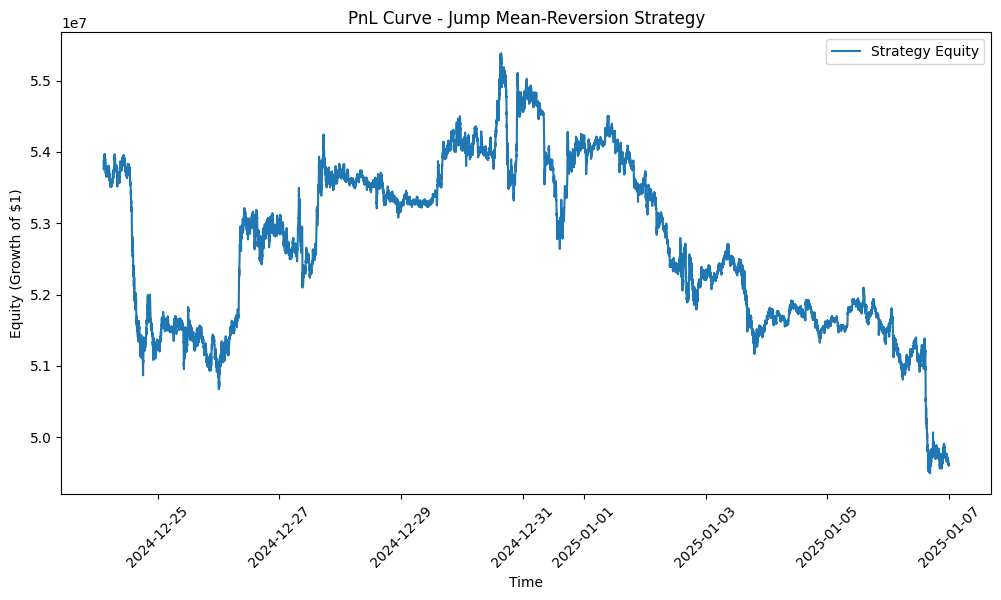

In [15]:
# Use a subset (important!)
sample = df.iloc[-20000:]  # last ~2 weeks of minutes

plt.figure(figsize=(12, 6))
plt.plot(sample['timestamp'], sample['cum_pnl_exp'], label='Strategy Equity')

plt.title("PnL Curve - Jump Mean-Reversion Strategy")
plt.xlabel("Time")
plt.ylabel("Equity (Growth of $1)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

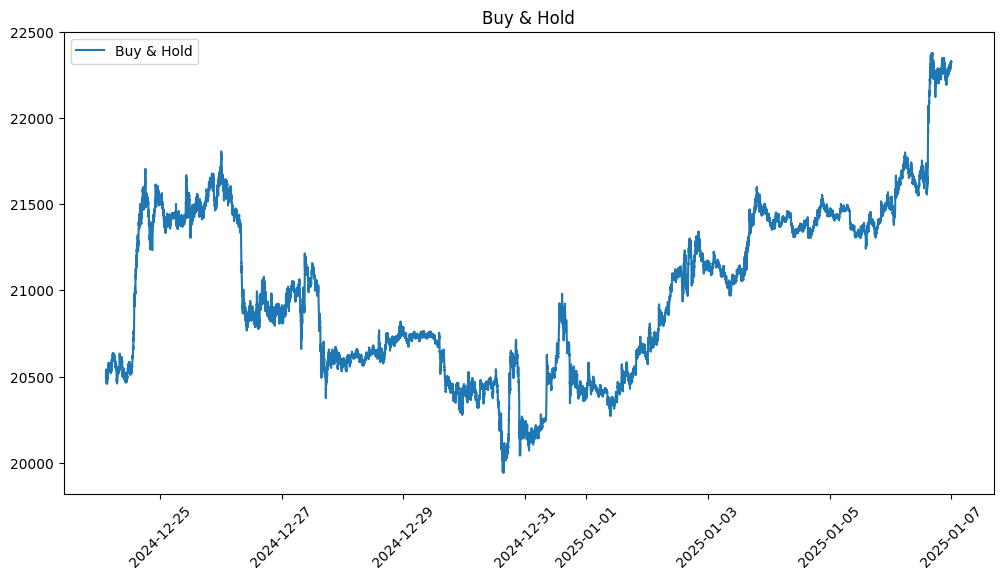

In [16]:
df['log_ret_clean'] = np.log(df['close'] / df['close'].shift(1))
df['buy_hold'] = np.exp(df['log_ret_clean'].cumsum())
sample = df.iloc[-20000:]
plt.figure(figsize=(12, 6))
#plt.plot(sample['timestamp'], sample['cum_pnl_exp'], label='Strategy')
plt.plot(sample['timestamp'], sample['buy_hold'], label='Buy & Hold')

plt.title("Buy & Hold")
plt.legend()
plt.xticks(rotation=45)
plt.show()

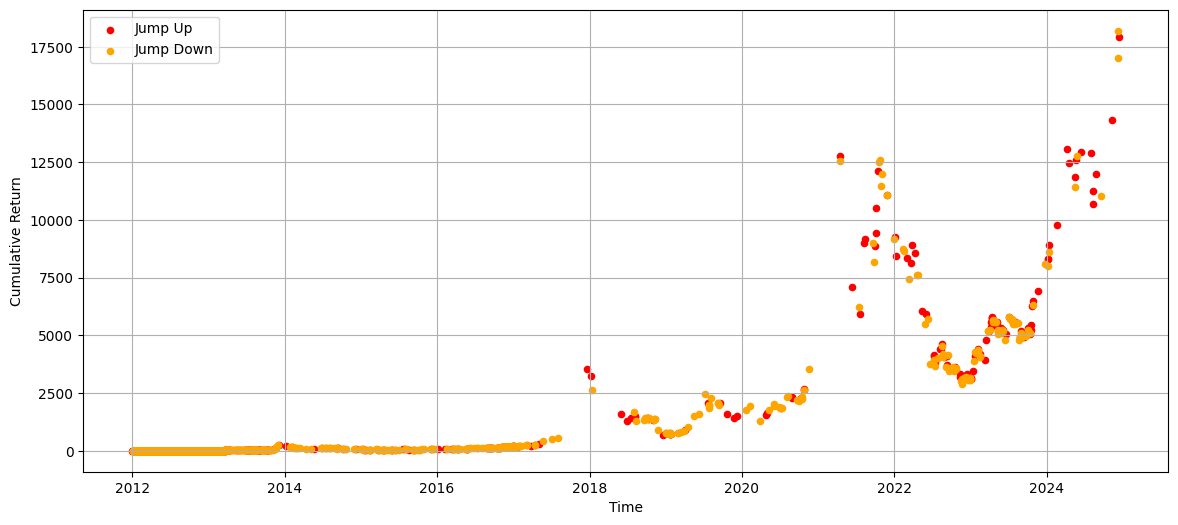

In [17]:
df['strategy_ret'] = df['position'].shift(1) * df['log_ret']  # assume trade at next minute
df['cum_strategy'] = df['strategy_ret'].cumsum().apply(np.exp)
df['cum_btc'] = df['log_ret'].cumsum().apply(np.exp)

plt.figure(figsize=(14,6))

plt.scatter(df.loc[df['jump_up'], 'timestamp'], df.loc[df['jump_up'], 'cum_btc'],
            color='red', s=20, label='Jump Up')
plt.scatter(df.loc[df['jump_down'], 'timestamp'], df.loc[df['jump_down'], 'cum_btc'],
            color='orange', s=20, label='Jump Down')

plt.xlabel('Time')
plt.ylabel('Cumulative Return')
plt.legend()
plt.grid()
plt.show()

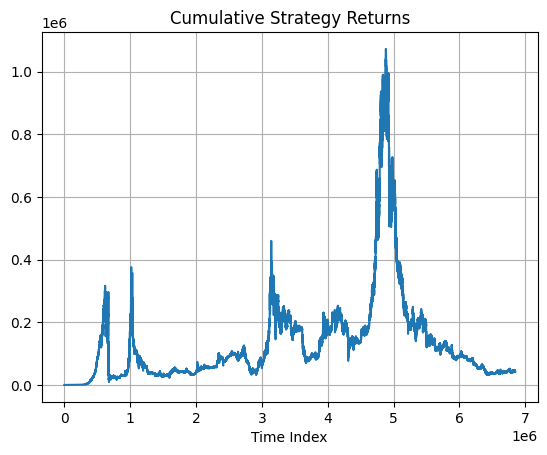

In [18]:
df['date'] = df['timestamp'].dt.date
daily = df.groupby('date').agg({
    'log_ret': 'sum',
    'strategy_ret': 'sum'
}).reset_index()

daily['cum_btc'] = daily['log_ret'].cumsum().apply(np.exp)
daily['cum_strategy'] = daily['strategy_ret'].cumsum().apply(np.exp)

df['ret'] = np.exp(df['log_ret']) - 1  # per-minute pct return
df['strategy_ret_pct'] = df['position'].shift(1) * df['ret']
df['cum_strategy_pct'] = (1 + df['strategy_ret_pct']).cumprod()
df['cum_btc_pct'] = (1 + df['ret']).cumprod()

df['cum_strategy_pct'].plot()
plt.grid()
plt.title("Cumulative Strategy Returns")
plt.xlabel("Time Index")
plt.show()

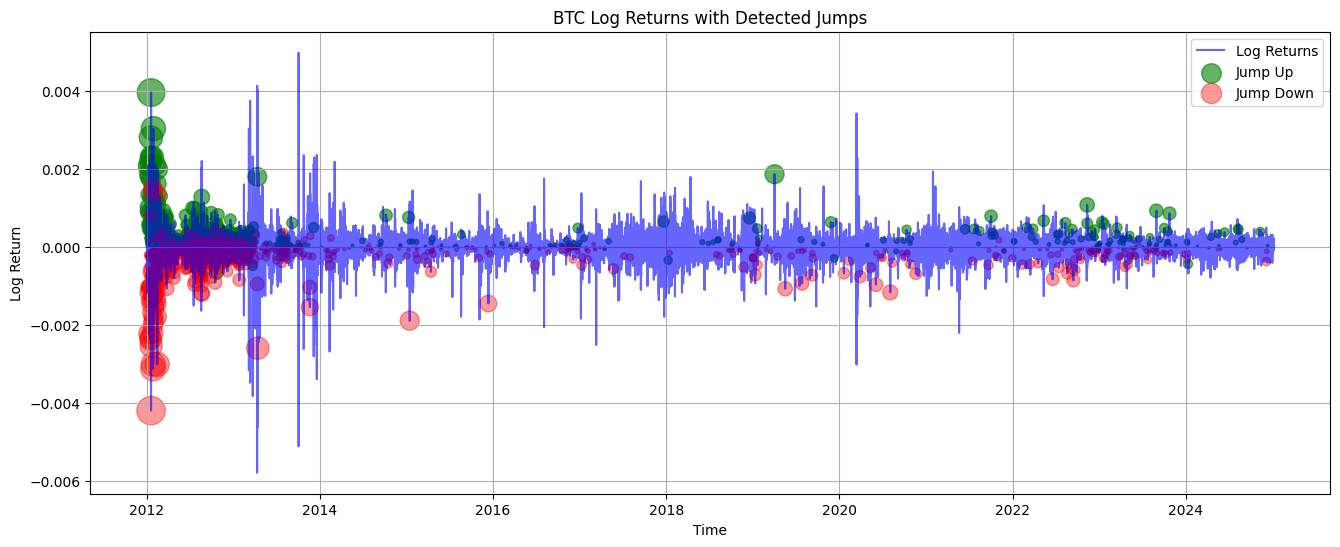

In [19]:
df_plot = df.resample('1h', on='timestamp').agg({
    'log_ret': 'mean',
    'vol': 'mean',
    'jump_up': 'max',
    'jump_down': 'max'
}).reset_index()

plt.figure(figsize=(16,6))

# Log returns line
plt.plot(df_plot['timestamp'], df_plot['log_ret'], color='blue', alpha=0.6, label='Log Returns')

# Highlight jumps with sized markers proportional to magnitude
plt.scatter(df_plot.loc[df_plot['jump_up'], 'timestamp'],
            df_plot.loc[df_plot['jump_up'], 'log_ret'],
            color='green', s=np.abs(df_plot.loc[df_plot['jump_up'], 'log_ret'])*1e5,
            label='Jump Up', alpha=0.6)

plt.scatter(df_plot.loc[df_plot['jump_down'], 'timestamp'],
            df_plot.loc[df_plot['jump_down'], 'log_ret'],
            color='red', s=np.abs(df_plot.loc[df_plot['jump_down'], 'log_ret'])*1e5,
            label='Jump Down', alpha=0.4)

plt.title('BTC Log Returns with Detected Jumps')
plt.xlabel('Time')
plt.ylabel('Log Return')
plt.legend()
plt.grid(True)
plt.show()

In [20]:
df['trade'] = (df['position'] != df['position'].shift(1)).astype(int)

num_trades = df['trade'].sum()
print("Number of Trades:", num_trades)

Number of Trades: 2190


In [21]:
# Strategy Win Rate
active = df['position'].shift(1) != 0
wins = (df['strategy_ret_pct'] > 0) & active
win_rate = wins.sum() / active.sum()
print("Win Rate (only trades):", win_rate)

print()

# The percentage of positive 1-min returns
wins = df['log_ret'] > 0
win_rate = wins.sum() / wins.count()
print("Win Rate:", win_rate)

Win Rate (only trades): 0.3648257157894137

Win Rate: 0.365841731662431


In [22]:
# Annualization factor for 1-min data (~365*24*60)
ann_factor = np.sqrt(365 * 24 * 60)

sharpe = df['strategy_ret'].mean() / df['strategy_ret'].std() * ann_factor
print("Sharpe Ratio:", sharpe)

Sharpe Ratio: 1.0213157071586383


In [23]:
df['cum_pnl'] = df['strategy_ret'].cumsum()
df['equity_curve'] = np.exp(df['cum_pnl'])

equity = df['equity_curve']
rolling_max = equity.cummax()
drawdown = (equity - rolling_max) / rolling_max

max_dd = drawdown.min()
print("Max Drawdown:", max_dd)

Max Drawdown: -0.9458945749272515


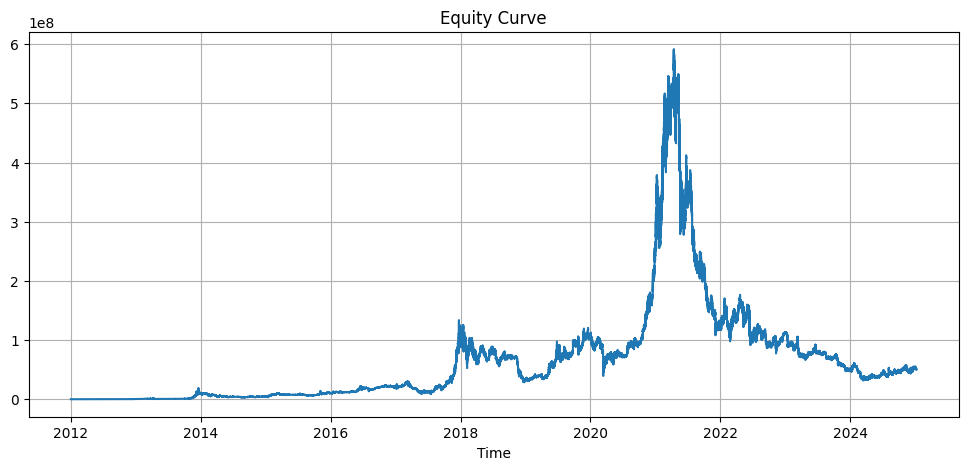

In [24]:
plt.figure(figsize=(12,5))
plt.plot(df['timestamp'], df['equity_curve'])
plt.title("Equity Curve")
plt.grid()
plt.xlabel("Time")
plt.show()

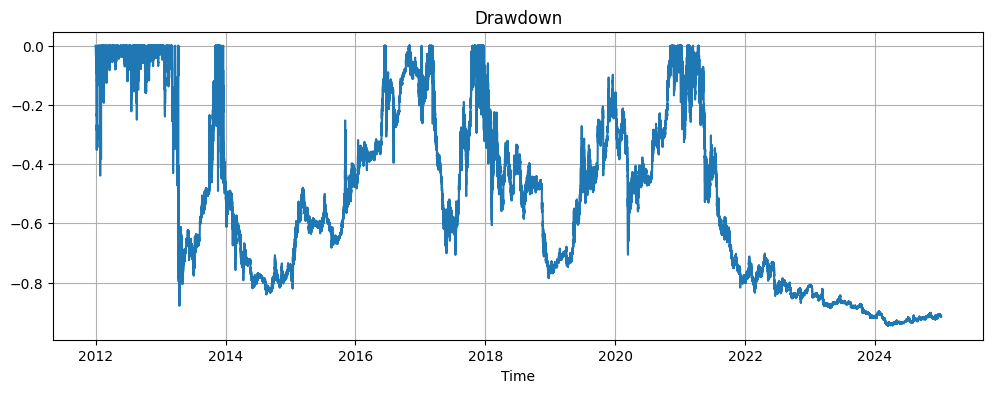

In [25]:
plt.figure(figsize=(12,4))
plt.plot(df['timestamp'], drawdown)
plt.title("Drawdown")
plt.grid()
plt.xlabel("Time")
plt.show()

In [26]:
total_return = df['cum_pnl'].iloc[-1] - 1
print("Total Return:", total_return)

Total Return: 16.719530169428527
